# EfficientNet-B3 (Basic)

**Objective**: This notebook applies the ResNet unfreeze recipe to EfficientNet-B3 without strong regularization, to test if the architecture is genuinely stronger when regularization doesn't get in the way.

**Architecture Changes**:
| Component | Previous iteration (EfficientNet-B3 Augmented) | This iteration (EfficientNet-B3 Basic) |
|---|---|---|
| Augmentation | Strong (v-flip, ±30°, ColorJitter, RandomAffine) | Basic (h-flip, ±10° rotation) |
| Optimizer | AdamW | Adam |
| Weight decay | 1e-4 | 0 |
| LR scheduler | CosineAnnealingLR | None |

**Hypothesis**: Every regularisation experiment (aug v1, aug v2, EfficientNet augmented) has consistently hurt recall compared to the plain ResNet unfreeze baseline. The hypothesis is that augmentation and weight decay make training harder and constrain the model too aggressively on this small dataset (~7,800 images), specifically hurting recall on the subtle visual patterns of melanoma. Removing them should improve recall.

## Import libraries, set seed, and choose device

In [1]:
import sys
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

from src.data.dataset import HAM10000Dataset
from src.data.dataloader import get_dataloaders
from src.data.transform import get_train_transforms
from src.models.efficientnet import get_efficientnet
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model

import pandas as pd

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


## Load and split data

In [2]:
train_dataset = HAM10000Dataset(
    csv_path=str(ROOT / 'data_new/splits/train.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    transform=get_train_transforms(image_size=224),
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    )

_, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / 'data_new/splits/train.csv'),
    val_csv=str(ROOT / 'data_new/splits/val.csv'),
    test_csv=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    test_image_dir=str(ROOT / 'data_new/images/test'),
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df     = pd.read_csv(ROOT / 'data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
pos_weight   = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)

Positive weight: tensor([8.1117], device='cuda:0')


## Model Definition

In [3]:
model = get_efficientnet(num_classes=1, freeze_backbone=False).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 20

L1_LAMBDA = 0.0
L2_LAMBDA = 0.0
dropout = 0.0

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')
print(f'L1 lambda: {L1_LAMBDA} | L2 lambda: {L2_LAMBDA} | Dropout: {dropout}')

Trainable params: 10,697,769 / 10,697,769
L1 lambda: 0.0 | L2 lambda: 0.0 | Dropout: 0.0


## Training Loop

In [4]:
best_val_auc = 0.0
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, device,
        l1_lambda=L1_LAMBDA, l2_lambda=L2_LAMBDA,
    )
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train | Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f}, AUC: {train_metrics['auc']:.4f}")
    print(f"  Val   | Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}, AUC: {val_metrics['auc']:.4f}")

    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        torch.save(model.state_dict(), str(ROOT / 'models/efficientnet_b3_best.pth'))
        print(f'  -> Saved best model (val AUC: {best_val_auc:.4f})')

Epoch [1/20]
  Train | Loss: 0.9434, Bal Acc: 0.7385, Recall: 0.8221, F2: 0.5393, AUC: 0.8124
  Val   | Loss: 0.8294, Bal Acc: 0.7634, Recall: 0.9322, F2: 0.5823, AUC: 0.8787
  -> Saved best model (val AUC: 0.8787)


Epoch [2/20]
  Train | Loss: 0.7647, Bal Acc: 0.7982, Recall: 0.8495, F2: 0.6154, AUC: 0.8804
  Val   | Loss: 0.8106, Bal Acc: 0.7715, Recall: 0.9110, F2: 0.5916, AUC: 0.8882
  -> Saved best model (val AUC: 0.8882)


Epoch [3/20]
  Train | Loss: 0.6885, Bal Acc: 0.8184, Recall: 0.8575, F2: 0.6449, AUC: 0.9035
  Val   | Loss: 0.7800, Bal Acc: 0.7904, Recall: 0.9364, F2: 0.6135, AUC: 0.8937
  -> Saved best model (val AUC: 0.8937)


Epoch [4/20]
  Train | Loss: 0.6334, Bal Acc: 0.8403, Recall: 0.8723, F2: 0.6786, AUC: 0.9198
  Val   | Loss: 0.7365, Bal Acc: 0.8109, Recall: 0.9025, F2: 0.6420, AUC: 0.9001
  -> Saved best model (val AUC: 0.9001)


Epoch [5/20]
  Train | Loss: 0.5942, Bal Acc: 0.8530, Recall: 0.8951, F2: 0.6962, AUC: 0.9281
  Val   | Loss: 0.7298, Bal Acc: 0.8047, Recall: 0.8347, F2: 0.6380, AUC: 0.8986


...

Epoch [16/20]
  Train | Loss: 0.2455, Bal Acc: 0.9446, Recall: 0.9544, F2: 0.8702, AUC: 0.9879
  Val   | Loss: 1.0457, Bal Acc: 0.7907, Recall: 0.7331, F2: 0.6232, AUC: 0.9013


Epoch [17/20]
  Train | Loss: 0.2679, Bal Acc: 0.9428, Recall: 0.9578, F2: 0.8640, AUC: 0.9855
  Val   | Loss: 1.0229, Bal Acc: 0.8115, Recall: 0.7500, F2: 0.6565, AUC: 0.9044


Epoch [18/20]
  Train | Loss: 0.2294, Bal Acc: 0.9514, Recall: 0.9612, F2: 0.8842, AUC: 0.9892
  Val   | Loss: 1.3167, Bal Acc: 0.7812, Recall: 0.6653, F2: 0.6109, AUC: 0.8960


Epoch [19/20]
  Train | Loss: 0.2365, Bal Acc: 0.9493, Recall: 0.9590, F2: 0.8799, AUC: 0.9889
  Val   | Loss: 1.1762, Bal Acc: 0.7976, Recall: 0.7373, F2: 0.6341, AUC: 0.9019


Epoch [20/20]
  Train | Loss: 0.1995, Bal Acc: 0.9604, Recall: 0.9749, F2: 0.9004, AUC: 0.9917
  Val   | Loss: 1.3476, Bal Acc: 0.7936, Recall: 0.6992, F2: 0.6303, AUC: 0.8973


## Plot Train and Validation Curves

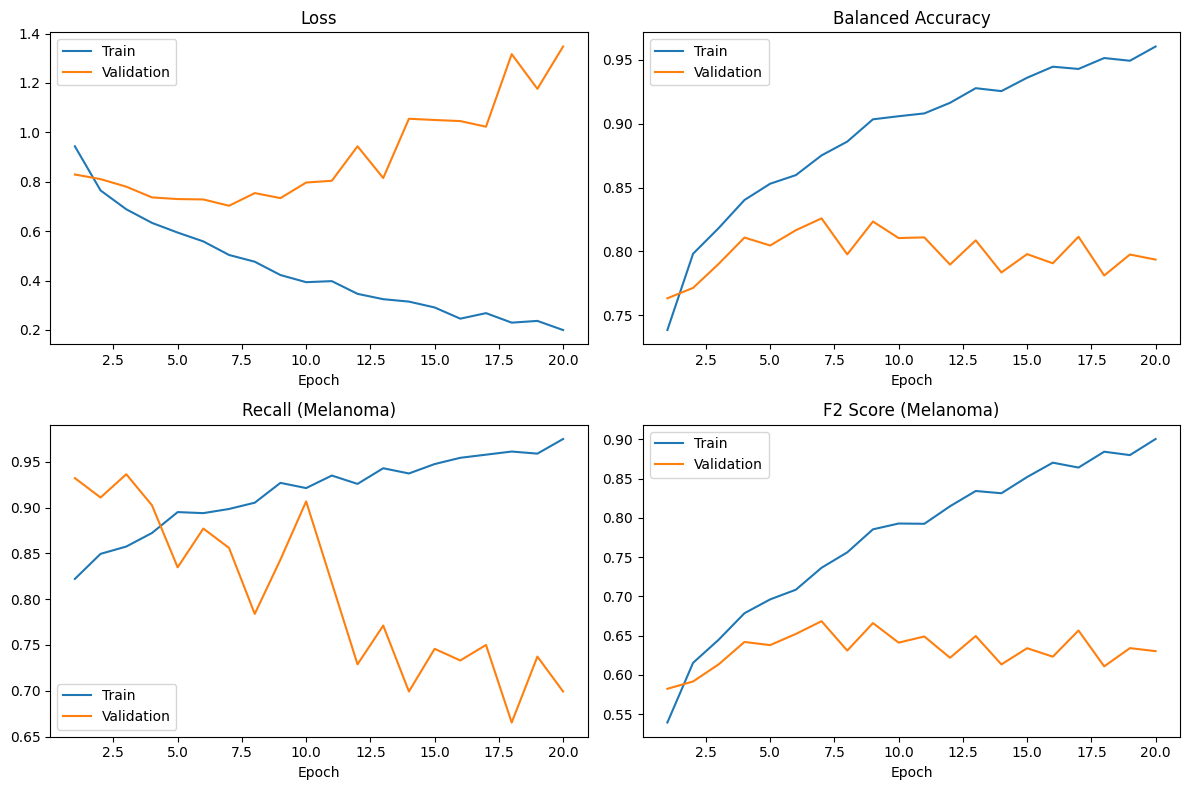

In [5]:
plot_training_curves(train_history, val_history)

## Threshold Tuning (Best Val F2)

In [6]:
model.load_state_dict(torch.load(str(ROOT / 'models/efficientnet_b3_best.pth'), map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

Best threshold: 0.55 | Val F2: 0.6685


## Test Set Evaluation

Threshold:          0.55
AUC-ROC:            0.9029
Balanced Accuracy:  0.8152
F2 Score:           0.6490

              precision    recall  f1-score   support

Non-Melanoma     0.9737    0.8000    0.8783      1340
    Melanoma     0.3463    0.8304    0.4888       171

    accuracy                         0.8034      1511
   macro avg     0.6600    0.8152    0.6836      1511
weighted avg     0.9027    0.8034    0.8342      1511



c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning\dl_venv\Lib\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


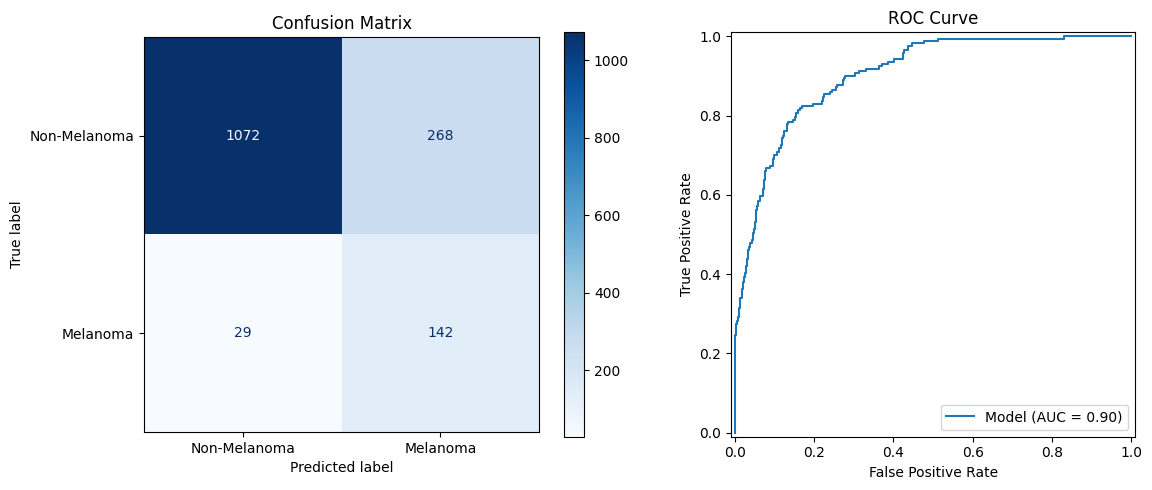

In [7]:
evaluate_model(model, test_loader, device, threshold=best_threshold)